In [1]:
import os
os.chdir(r"..\models\..")

import math
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
from torch.utils.data import Dataset, DataLoader, random_split

from tokenizer import Tokenizer
from text_generator import TextGenerator

In [2]:
# Training Tokenizer
data = "data\\my_essays_data.txt"

with open(data, "r", encoding="utf-8") as f:
    text = f.read()

tokenizer = Tokenizer(vocab_size=100_000)
tokenizer.fit([text])

vocab_size = len(tokenizer.word_to_idx)
#print(f"Vocabulary Size: {vocab_size}")

with open("models/generator_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [3]:
class TextDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len
        self.stride = seq_len // 2

    def __len__(self):
        return (len(self.tokens) - self.seq_len) // self.stride
    
    def __getitem__(self, idx):

        start = idx * self.stride

        x = self.tokens[start:start + self.seq_len]
        y = self.tokens[start + 1:start + self.seq_len + 1]
       
        return torch.tensor(x), torch.tensor(y)

In [4]:
# Plotting Metrics Function
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, perplexities):
    epochs = range(1, len(val_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plotting
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()
    plt.legend()

    # Accuracy Plotting
    plt.subplot(1, 3, 2)
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss")
    plt.grid()
    plt.legend()
    
    # Perplexity Plotting
    plt.subplot(1, 3, 3)
    plt.plot(epochs, perplexities, label="Perplexity")
    plt.xlabel("Epoch")
    plt.ylabel("Perplexity")
    plt.title("Perplexity per Epoch")
    plt.grid()
    plt.legend()
    
    plt.tight_layout()
    plt.show()


CUDA available: True
CUDA device name: NVIDIA GeForce GTX 1660
Epoch 1, Train Loss: 8.0815, Val Loss: 7.7722, Perplexity: 2373.79
Epoch 10, Train Loss: 6.2590, Val Loss: 6.2864, Perplexity: 537.22
Epoch 20, Train Loss: 5.8685, Val Loss: 5.7807, Perplexity: 323.98
Epoch 30, Train Loss: 5.4625, Val Loss: 5.3436, Perplexity: 209.26
Epoch 40, Train Loss: 5.0759, Val Loss: 4.9761, Perplexity: 144.91
Epoch 50, Train Loss: 4.6997, Val Loss: 4.3831, Perplexity: 80.09
Epoch 60, Train Loss: 4.3742, Val Loss: 4.0563, Perplexity: 57.76
Epoch 70, Train Loss: 4.0633, Val Loss: 3.8029, Perplexity: 44.83
Epoch 80, Train Loss: 3.7590, Val Loss: 3.4152, Perplexity: 30.42
Epoch 90, Train Loss: 3.4681, Val Loss: 3.0100, Perplexity: 20.29
Epoch 100, Train Loss: 3.1892, Val Loss: 2.6932, Perplexity: 14.78
Epoch 110, Train Loss: 2.9334, Val Loss: 2.3685, Perplexity: 10.68
Epoch 120, Train Loss: 2.6931, Val Loss: 2.0628, Perplexity: 7.87


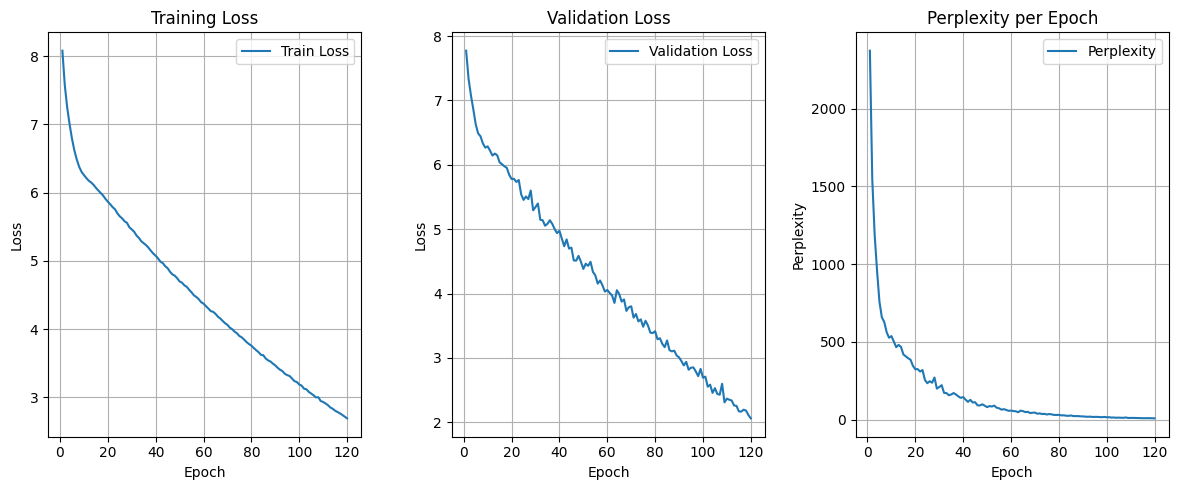

In [ ]:
# Training the model
dataset = TextDataset(tokenizer.transform(text), seq_len=100)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TextGenerator(
    vocab_size=vocab_size,
    embedding_dim=128,
    num_layers=3,
    num_heads=4,
    d_ff=512,
    max_len=128,
    dropout=0.1,
    device=device
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=100):

    best_val_loss = float("inf")

    train_losses = []
    val_losses = []
    perplexities = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            output = model(x)

            loss = criterion(output.reshape(-1, output.shape[-1]), y.reshape(-1))
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            x = x.to(device)
            y = y.to(device)

            output = model(x)
            loss = criterion(output.reshape(-1, output.shape[-1]), y.reshape(-1))
            val_loss += loss.item()

        val_loss /= len(val_loader)
        perplexity = math.exp(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        perplexities.append(perplexity)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Perplexity: {perplexity:.2f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "models/generator_best_model.pt")

    plot_metrics(train_losses, val_losses, perplexities)

print("\nCUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
train(model, train_loader, val_loader, criterion, optimizer, device, epochs=120)


In [6]:
# Trying model
with open("models/generator_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TextGenerator(
    vocab_size=vocab_size,
    embedding_dim=128,
    num_layers=3,
    num_heads=4,
    d_ff=512,
    max_len=128,
    dropout=0.1,
    device=device
).to(device)

model.load_state_dict(torch.load("models/generator_best_model.pt", map_location=device))

model.eval()

def generation_text(model, tokenizer, prompt, max_new_tokens=50):
    model.eval()

    tokens = tokenizer.transform(prompt)
    tokens = torch.tensor(tokens).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(tokens)

        next_token_logits = logits[:, -1, :]
        probs = torch.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        tokens = torch.cat([tokens, next_token], dim=-1)

    generated = tokens.squeeze().tolist()

    words = [tokenizer.idx_to_word.get(t, "<UNK>") for t in generated]
    lines = [" ".join(words[i:i+10]) for i in range(0, len(words), 10)]

    return "\n".join(lines)

print("Text generation to my prompt:\n")
print(generation_text(
    model,
    tokenizer,
    prompt="I was very happy because today I did",
    max_new_tokens=50
))

Text generation to my prompt:

i was very happy because today i did and that
he gathering consciousness that without preferable . i want to
explain older 178 individuals and then . just recently for
me against me everyone , i want to use at
the spiritual into the way allowing about the apparition and
i ’ s story that so much to
